# Task 4 - ArcFace

## 1. Objective and ArcFace theory

Multi-Similarity weighting improved one hard-tail geometry diagnostic but did not surpass SupCon on any ranking metric. This suggests that repeatedly reweighting relations available in the current batch is not enough for the coarse, long-tailed joint classes. ArcFace changes the source of supervision: rather than organising training only around image pairs, it learns a persistent proxy centre for every class.

The embedding $x_i$ and each class weight $W_j$ are L2-normalised, so their dot product becomes $\cos(\theta_j)$ and classification depends only on angle. For the target class, ArcFace replaces the ordinary target logit with

$$s\cos(\theta_{y_i}+m).$$

Adding angular margin $m$ makes the correct class deliberately harder to reach and therefore encourages tighter within-class grouping and clearer inter-class separation on the hypersphere [1]. Scale $s$ restores a useful logit and gradient magnitude after normalisation [2]. The class weights act as centres only during training; the head is discarded at inference, leaving the same 512-D encoder and cosine-search interface as the other supervised candidates.


### ArcFace training rule

<div align="center"><img src="figures/05_arcface_paper_figure2.png" width="980" alt="ArcFace feature and class-weight normalisation, angular margin and softmax loss"></div>

*Figure 1. ArcFace normalises the feature and class weights, adds angular margin $m$ to the target angle, rescales the logits, and applies softmax cross-entropy. Reproduced from Fig. 2 in [1].*

The full training path makes the role of each hyperparameter concrete. Normalisation changes each class weight into a persistent direction, **$m$ increases the target-class angle before classification**, and **$s$ restores the logit scale** needed for stable optimisation. Unlike the pair-based losses, the class centre survives across batches. The next schematic isolates the angular geometry that matters for the 512-D cosine embedding retained at inference.


### Angular geometry used in this notebook

![ArcFace angular-margin mechanism](figures/05_arcface_mechanism.svg)

*Figure 2. Features and class centres lie on a hypersphere; the target angle receives an additive margin before scaled softmax. Original schematic based on [1].*


## 2. Model rationale

The dataset contains 249 joint classes, but a batch sees only 16 of them at a time. A learned proxy centre persists across batches and accumulates a global direction for its class even when individual products are not sampled together. This is especially attractive after the pair-weighting experiment, whose local geometry improvement did not translate into a better top-K list.

ArcFace also trains in the same angular geometry used by cosine retrieval. The margin and scale cannot simply be copied from face recognition. Fashion classes have wider variation in colour, pattern and silhouette, and their frequencies are imbalanced. Both values are therefore tuned, and a smaller selected margin should be interpreted as gentler separation for this particular proxy rather than a universal property of fashion data.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from pytorch_metric_learning import losses
from tqdm.auto import tqdm

from src.task4.config import (
    CONFIG_DIR,
    EARLY_STOPPING_PATIENCE,
    FINAL_EPOCHS,
    HISTORY_DIR,
    IMAGE_DIR,
    INPUT_SIZE,
    LABEL_COLUMN,
    LABEL_ID_COLUMN,
    MIN_CLASS_SIZE,
    MIN_DELTA,
    MODEL_DIR,
    N_TRIALS,
    PLOT_DIR,
    SEED,
    SPLIT_DIR,
    TUNING_EPOCHS,
    VAL_FRACTION,
)
from src.task4.data import (
    make_evaluation_loader,
    make_metric_training_loader,
    make_metric_validation_loss_loader,
)
from src.task4.models import ResNet18Encoder
from src.task4.preprocessing import (
    metric_eval_transform,
    metric_preprocessing_config,
    metric_train_transform,
)
from src.task4.retrieval import (
    evaluate_retrieval,
    extract_color_descriptors,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import (
    AMP_ENABLED,
    DEVICE,
    EarlyStopping,
    cpu_state_dict,
    evaluate_loss,
    new_optimizer_and_scheduler,
    set_seed,
    train_one_epoch,
)
from src.task4.tuning import create_study, load_best_params


## 3. Data and validation split
The same 30,389/3,378 inner train-validation split, class filtering, four-per-class sampler, augmentation, 2,861-item tuning gallery, and deterministic evaluation transform are reused. This is essential: ArcFace's higher score is meaningful only if it does not receive a different gallery, backbone, or test access.

Labels index the train-fitted class centres. Encoder-unseen outer-test classes remain excluded later because there is no centre or relevant training gallery item for a closed-set measurement.


In [3]:
set_seed(SEED)
print("Device:", DEVICE, "| Mixed precision:", AMP_ENABLED)


Device: cuda | Mixed precision: True


In [3]:
outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder_config = json.load(file)

classes = label_encoder_config["classes"]
label_to_index = label_encoder_config["label_to_index"]

outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + "__"
    + outer_train_df["gender"].str.strip()
)

outer_train_df[LABEL_ID_COLUMN] = (
    outer_train_df[LABEL_COLUMN].map(label_to_index).astype("int64")
)

outer_class_counts = outer_train_df[LABEL_COLUMN].value_counts()
eligible_labels = set(outer_class_counts[outer_class_counts >= MIN_CLASS_SIZE].index)
development_df = outer_train_df[
    outer_train_df[LABEL_COLUMN].isin(eligible_labels)
].copy()


In [4]:
inner_stratify_columns = ["articleType", "gender"]
inner_stratify_features = pd.get_dummies(
    development_df[inner_stratify_columns].astype(str),
    prefix=inner_stratify_columns,
)
inner_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_FRACTION,
    random_state=SEED,
)
inner_train_idx, inner_val_idx = next(
    inner_splitter.split(development_df, inner_stratify_features)
)
train_df = development_df.iloc[inner_train_idx].copy()
val_df = development_df.iloc[inner_val_idx].copy()

train_counts = train_df[LABEL_ID_COLUMN].value_counts()
valid_label_ids = train_counts[train_counts >= MIN_CLASS_SIZE].index
train_df = train_df[train_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()
val_df = val_df[val_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()

overlap = set(train_df["id"]) & set(val_df["id"])
if overlap:
    raise ValueError(f"Inner split contains {len(overlap)} overlapping IDs")
if val_df[LABEL_ID_COLUMN].isna().any():
    raise ValueError("Inner validation contains an unmapped label")


In [8]:
gallery_parts = []
for _, group in train_df.groupby(LABEL_COLUMN, sort=True):
    sample_size = min(20, len(group))
    gallery_parts.append(group.sample(sample_size, random_state=SEED))

tuning_gallery_df = pd.concat(gallery_parts).sort_values("id").reset_index(drop=True)

print(f"Model train/validation: {len(train_df):,}/{len(val_df):,}")
print("Excluded rare rows:", len(outer_train_df) - len(development_df))
print("Tuning gallery rows:", len(tuning_gallery_df))


Model train/validation: 30,389/3,378
Excluded rare rows: 153
Tuning gallery rows: 2861


In [5]:
def make_arcface_loaders(train_frame, gallery_frame, query_frame):
    return {
        "train": make_metric_training_loader(train_frame, metric_train_transform, IMAGE_DIR),
        "gallery": make_evaluation_loader(gallery_frame, metric_eval_transform, IMAGE_DIR),
        "query": make_evaluation_loader(query_frame, metric_eval_transform, IMAGE_DIR),
    }

def compute_arcface_loss(model, loss_function, batch):
    images = batch["image"].to(DEVICE, non_blocking=True)
    labels = batch["label"].to(DEVICE, non_blocking=True)
    return loss_function(model(images), labels)


## 4. Hyperparameter tuning

The 20-trial, 15-epoch Optuna screen maximises capped-gallery validation mAP@10 [4]. Learning rate controls how quickly the from-scratch encoder changes, while weight decay regularises the encoder and—during final training—the class centres. Angular margin is searched from 0.1 to 0.5 radians because too little margin may not separate classes, whereas too much can make a heterogeneous class difficult to fit. Scale is selected from 16, 32, 48 and 64 to balance weak normalised logits against an excessively sharp softmax.

| Parameter | Search range | Selected value |
|---|---:|---:|
| learning rate | `3e-5` to `1e-3` (log) | `2.94e-4` |
| weight decay | `1e-6` to `3e-4` (log) | `7.39e-5` |
| angular margin | `0.1` to `0.5` radians | `0.1297` radians |
| scale | `{16, 32, 48, 64}` | `16` |

The selected margin is approximately 7.4 degrees and the smallest scale is preferred, which is consistent with gentler supervision for visually diverse joint classes. There is nevertheless an important implementation caveat. During the saved tuning objective, `ArcFaceLoss` was not attached to the model before the optimizer was created, so the class-centre parameters were fixed during that screen. Final training correctly attaches and optimises them. The saved HPO result should therefore be described as an approximate parameter screen, and a fresh study is required before claiming a fully matched ArcFace optimisation.


In [6]:
def arcface_objective(trial: optuna.Trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 3e-5, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 3e-4, log=True),
        "margin": trial.suggest_float("margin", 0.1, 0.5),
        "scale": trial.suggest_categorical("scale", [16, 32, 48, 64]),
    }
    set_seed(SEED)
    model = ResNet18Encoder()
    loss_function = losses.ArcFaceLoss(
        num_classes=len(classes),
        embedding_size=512,
        margin=math.degrees(parameters.get("margin", 0.3)),
        scale=parameters.get("scale", 32),
    )
    model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
    loaders = make_arcface_loaders(train_df, tuning_gallery_df, val_df)
    optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    best_score = -math.inf
    for epoch in tqdm(range(1, TUNING_EPOCHS + 1), desc="arcface tuning"):
        train_one_epoch(
            model, loss_function, compute_arcface_loss, loaders["train"], optimizer, scaler, epoch
        )
        score = evaluate_retrieval(model, loaders["gallery"], loaders["query"])[
            "mAP@10"
        ]
        scheduler.step(score)
        best_score = max(best_score, score)
        trial.report(score, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_score

In [9]:
arcface_study = create_study("task4_arcface")
arcface_study.optimize(arcface_objective, n_trials=N_TRIALS)

print("arcface", "best parameters:", arcface_study.best_params)
print("arcface", "tuned validation mAP@10:", arcface_study.best_value)

[I 2026-09-08 18:30:56,670] A new study created in RDB with name: task4_arcface


arcface tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-08 18:33:59,136] Trial 0 finished with value: 0.5811558068313175 and parameters: {'learning_rate': 0.00011155792840695785, 'weight_decay': 0.0002264824818951685, 'margin': 0.39279757672456206, 'scale': 16}. Best is trial 0 with value: 0.5811558068313175.


arcface tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-08 18:36:58,119] Trial 1 finished with value: 0.6193344775249748 and parameters: {'learning_rate': 0.0006254642575696304, 'weight_decay': 3.083434817935579e-05, 'margin': 0.3832290311184182, 'scale': 32}. Best is trial 1 with value: 0.6193344775249748.


...

arcface tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-08 19:10:31,840] Trial 18 pruned. 


arcface tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-08 19:13:34,887] Trial 19 finished with value: 0.6263093201888348 and parameters: {'learning_rate': 0.000255461706185348, 'weight_decay': 1.2305886243194174e-05, 'margin': 0.1995922742147319, 'scale': 16}. Best is trial 16 with value: 0.6318796431390793.


arcface best parameters: {'learning_rate': 0.00029433520076739664, 'weight_decay': 7.388862395491402e-05, 'margin': 0.12971904269571718, 'scale': 16}
arcface tuned validation mAP@10: 0.6318796431390793


### 4.1 Hyperparameter evidence


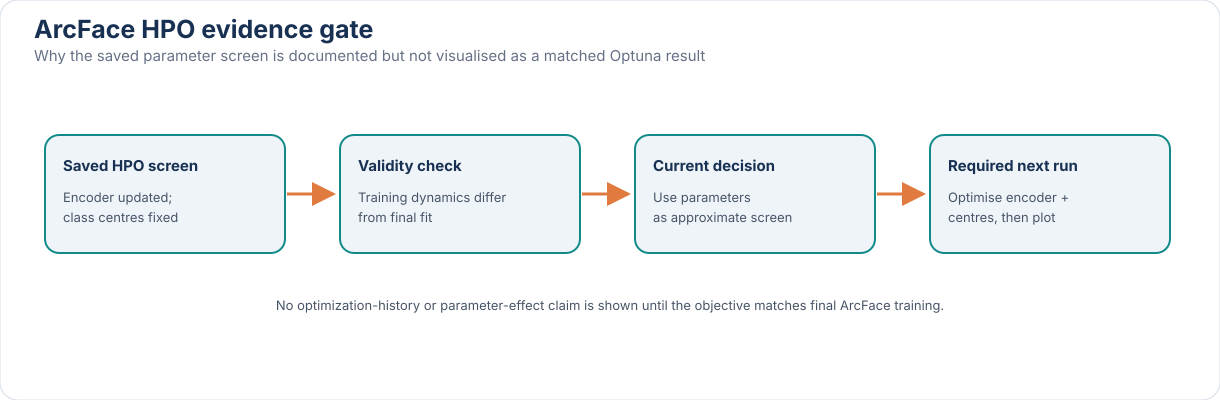

In [1]:
from pathlib import Path
from IPython.display import SVG, display

figure_path = Path("notebooks/task4/figures/05_arcface_hpo_validity_gate.svg")
if not figure_path.exists():
    figure_path = Path("figures/05_arcface_hpo_validity_gate.svg")
display(SVG(filename=str(figure_path)))


*Figure 3. Evidence gate applied to the saved ArcFace parameter screen before any Optuna history is interpreted.*

The saved database is intentionally not plotted as if it were a fully matched search. During that screen, the optimizer updated **the encoder but not the ArcFace class centres**, whereas final training updates both. An attractive optimization-history or margin/scale plot would therefore visualise a different training system and could overstate the strength of the hyperparameter evidence. The current values can still be reported as an approximate screen because they produced the recorded final model. A **fresh study with the loss attached before optimizer construction** is still required before interpreting trial paths or parameter effects.


## 5. Final training and checkpoint selection
The final section correctly attaches `ArcFaceLoss` to the model before creating AdamW, so both encoder weights and class centres are optimised and saved. The same scheduler, mixed precision, 60-epoch ceiling, and mAP@10 checkpoint rule are used as for the other candidates.

The best state occurs at epoch 58; the slight decline in epochs 59-60 validates checkpoint selection. Because the tuning caveat remains, the final score demonstrates that this trained configuration is strong, but it does not prove the reported hyperparameters are optimal.


In [10]:
arcface_history = []
arcface_best_epoch = 0
arcface_best_score = -math.inf

arcface_best_params, arcface_tuning_best_value = load_best_params("task4_arcface")
print("arcface loaded Optuna best parameters:", arcface_best_params)
print("arcface tuned validation mAP@10:", arcface_tuning_best_value)

parameters = arcface_best_params
set_seed(SEED)
model = ResNet18Encoder()
model.arcface_loss = losses.ArcFaceLoss(
    num_classes=len(classes),
    embedding_size=512,
    margin=math.degrees(parameters.get("margin", 0.3)),
    scale=parameters.get("scale", 32),
)
loss_function = model.arcface_loss
model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
loaders = make_arcface_loaders(train_df, tuning_gallery_df, val_df)
val_loss_loader = make_metric_validation_loss_loader(
    val_df, metric_eval_transform, IMAGE_DIR
)


arcface loaded Optuna best parameters: {'learning_rate': 0.00029433520076739664, 'weight_decay': 7.388862395491402e-05, 'margin': 0.12971904269571718, 'scale': 16}
arcface tuned validation mAP@10: 0.6318796431390793


In [11]:
optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
stopper = EarlyStopping(EARLY_STOPPING_PATIENCE, MIN_DELTA)
best_state = None


In [12]:
for epoch in tqdm(range(1, FINAL_EPOCHS + 1), desc="arcface final"):
    train_loss = train_one_epoch(
        model, loss_function, compute_arcface_loss, loaders["train"], optimizer, scaler, epoch
    )
    val_loss = evaluate_loss(model, loss_function, compute_arcface_loss, val_loss_loader)
    metrics = evaluate_retrieval(model, loaders["gallery"], loaders["query"])
    score = metrics["mAP@10"]
    scheduler.step(score)
    if stopper.update(score):
        best_state = cpu_state_dict(model)
        arcface_best_epoch = epoch
    arcface_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_map_at_10": score,
        }
    )
    print("arcface", epoch, "loss:", round(train_loss, 4), "mAP@10:", round(score, 4))
    if stopper.should_stop:
        break


arcface final:   0%|          | 0/60 [00:00<?, ?it/s]

arcface 1 loss: 5.1187 mAP@10: 0.2169
arcface 2 loss: 3.0829 mAP@10: 0.2978
arcface 3 loss: 2.2704 mAP@10: 0.3712
arcface 4 loss: 1.808 mAP@10: 0.416
arcface 5 loss: 1.5159 mAP@10: 0.4302
arcface 6 loss: 1.3307 mAP@10: 0.4634
arcface 7 loss: 1.1609 mAP@10: 0.5091
arcface 8 loss: 1.0101 mAP@10: 0.5224
arcface 9 loss: 0.9556 mAP@10: 0.5479
arcface 10 loss: 0.8661 mAP@10: 0.5657
arcface 11 loss: 0.7611 mAP@10: 0.5569
arcface 12 loss: 0.7585 mAP@10: 0.5867
arcface 13 loss: 0.6971 mAP@10: 0.5723
arcface 14 loss: 0.6586 mAP@10: 0.5987
arcface 15 loss: 0.6182 mAP@10: 0.6196
arcface 16 loss: 0.5972 mAP@10: 0.6265
arcface 17 loss: 0.5582 mAP@10: 0.6294
arcface 18 loss: 0.5274 mAP@10: 0.6457
arcface 19 loss: 0.4999 mAP@10: 0.6388
arcface 20 loss: 0.4703 mAP@10: 0.6455
arcface 21 loss: 0.4522 mAP@10: 0.6631
arcface 22 loss: 0.4477 mAP@10: 0.6641
arcface 23 loss: 0.4307 mAP@10: 0.6682
arcface 24 loss: 0.4137 mAP@10: 0.6623
arcface 25 loss: 0.3982 mAP@10: 0.6711
arcface 26 loss: 0.3808 mAP@10: 0.66

In [13]:
model.load_state_dict(best_state)
arcface_best_score = stopper.best_score
arcface_model = model
print("arcface", "best epoch:", arcface_best_epoch, "best mAP@10:", arcface_best_score)


arcface best epoch: 58 best mAP@10: 0.7892732620974185


## 6. Training curves
The capped-gallery validation mAP@10 rises to **0.789** at epoch 58 while the loss generally falls. The curve is materially above SupCon under the same inner protocol and does not rely on a favourable last epoch. Validation loss is higher than training loss, but its absolute ArcFace scale should not be compared with other objectives.

The two post-peak epochs are too few to trigger patience-10 early stopping, so the run ends at the shared budget while retaining epoch 58.


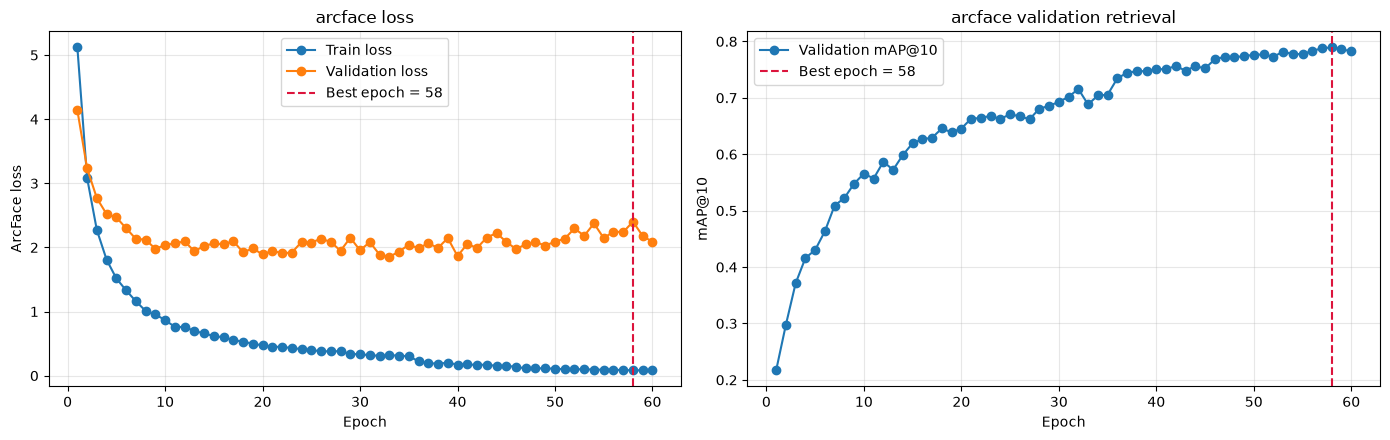

In [14]:
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

history_path = HISTORY_DIR / "arcface_history.csv"
pd.DataFrame(arcface_history).sort_values("epoch").to_csv(history_path, index=False)
history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss"
)
axes[0].plot(
    history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss"
)
axes[0].axvline(
    arcface_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {arcface_best_epoch}",
)
axes[0].set_title("arcface loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ArcFace loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["val_map_at_10"],
    marker="o",
    label="Validation mAP@10",
)
axes[1].axvline(
    arcface_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {arcface_best_epoch}",
)
axes[1].set_title("arcface validation retrieval")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@10")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(PLOT_DIR / "arcface_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Model artifact and inner-validation evaluation
The checkpoint keeps the ArcFace training head as part of the artifact record. Notebook 06 removes `arcface_loss.*` and deploys only the common ResNet-18 encoder. Consequently, ArcFace's better retrieval does not require a larger inference backbone than Triplet, SupCon, or MS. The searchable gallery remains the paired embedding/ID arrays distributed outside Git.

The saved full-gallery diagnostic gives raw mAP@10 of **0.799** and reranked mAP@10 of **0.799** (a gain of roughly 0.0006). Most value therefore comes from the learned embedding; reranking is a small, non-universal adjustment.


In [15]:
model_directory = MODEL_DIR / "arcface"
model_directory.mkdir(parents=True, exist_ok=True)
checkpoint = {
    "model_name": "arcface",
    "model_state_dict": cpu_state_dict(arcface_model),
    "model_config": {
        "backbone": "resnet18",
        "pretrained": False,
        "input_size": list(INPUT_SIZE),
        "embedding_dimension": 512,
        "class_count": len(classes),
    },
    "best_params": arcface_best_params,
    "best_epoch": arcface_best_epoch,
    "best_val_map_at_10": arcface_best_score,
    "preprocessing_config": metric_preprocessing_config,
    "label_to_index": label_to_index,
    "gallery_scope": "eligible_inner_training",
    "random_seed": SEED,
}
torch.save(checkpoint, model_directory / "best.pt")
print("Saved:", model_directory / "best.pt")


Saved: /workspace/Machine-Learning-Assignment-2/artifacts/task4/models/arcface/best.pt


In [16]:
gallery_loader = make_evaluation_loader(train_df, metric_eval_transform, IMAGE_DIR)
gallery_embeddings, gallery_ids, gallery_labels = extract_embeddings(
    arcface_model, gallery_loader
)
np.save(model_directory / "gallery_embeddings.npy", gallery_embeddings)
np.save(model_directory / "gallery_ids.npy", gallery_ids)


In [17]:
query_loader = make_evaluation_loader(val_df, metric_eval_transform, IMAGE_DIR)
query_embeddings, query_ids, query_labels = extract_embeddings(arcface_model, query_loader)


In [18]:
_, base_indices, index = search_cosine(query_embeddings, gallery_embeddings)
query_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in query_ids
)
gallery_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in gallery_ids
)
reranked_indices = k_reciprocal_rerank(
    query_embeddings,
    gallery_embeddings,
    index,
    query_color_descriptors=query_color_descriptors,
    gallery_color_descriptors=gallery_color_descriptors,
    color_weight=0.15,
)
print("arcface", "base:", retrieval_metrics(base_indices, query_labels, gallery_labels))
print(
    "arcface",
    "reranked:",
    retrieval_metrics(reranked_indices, query_labels, gallery_labels),
)


arcface base: {'Precision@1': 0.8206039076376554, 'Recall@1': 0.0034974060944886116, 'Precision@5': 0.8194197750148017, 'Recall@5': 0.017758834720997905, 'Precision@10': 0.8165778567199526, 'Recall@10': 0.033791982096195425, 'mAP@10': 0.798871726014266}
arcface reranked: {'Precision@1': 0.8229721728833629, 'Recall@1': 0.00356386790543347, 'Precision@5': 0.8171107164002368, 'Recall@5': 0.017834826804554744, 'Precision@10': 0.8150384843102428, 'Recall@10': 0.03421785660081374, 'mAP@10': 0.799468736653708}


## 8. Comparison with previous models and benchmark selection

| Model | Precision@1 | Precision@5 | Precision@10 | Recall@10 | mAP@10 |
|---|---:|---:|---:|---:|---:|
| Multi-Similarity | 0.7697 | 0.7552 | 0.7498 | 0.0325 | 0.6935 |
| SupCon (previous best) | 0.8005 | 0.7934 | 0.7883 | 0.0335 | 0.7486 |
| **ArcFace** | **0.8206** | **0.8194** | **0.8166** | **0.0338** | **0.7989** |

ArcFace recovers the performance lost by Multi-Similarity and also outperforms the previous best model, SupCon. Relative to MS, Precision@1 rises by 0.0509 and mAP@10 by 0.1054. Relative to SupCon, the advantage remains visible at every displayed K. ArcFace is also the only candidate for which reranking produces a small positive mAP change, from 0.7989 to 0.7995, although that gain is too small to explain the ranking.

Its embedding geometry adds a useful qualification. SupCon has the largest mean same-versus-different gap, but ArcFace reduces the standard deviation of different-class similarities from 0.2040 to 0.0668 and achieves the best robust gap, 0.4432. ArcFace does not win by maximising the average gap. It controls the hard-negative tail more consistently, which better matches the need for a clean top-K list.

ArcFace becomes the leading inner-validation candidate, although the single seed, fixed epoch budget and class-centre HPO caveat limit the strength of the claim. At this point, adding another model would no longer answer the main question. Model development stops, every candidate is frozen, and `06_final_benchmark.ipynb` opens the untouched outer hold-out once to determine whether the ordering survives on unseen queries.


## References

[1] J. Deng, J. Guo, N. Xue, and S. Zafeiriou, "ArcFace: Additive angular margin loss for deep face recognition," in *Proc. IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2019, pp. 4690-4699. [Online]. Available: https://openaccess.thecvf.com/content_CVPR_2019/html/Deng_ArcFace_Additive_Angular_Margin_Loss_for_Deep_Face_Recognition_CVPR_2019_paper.html

[2] X. Zhang, R. Zhao, Y. Qiao, X. Wang, and H. Li, "AdaCos: Adaptively scaling cosine logits for effectively learning deep face representations," in *Proc. IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2019, pp. 10823-10832. [Online]. Available: https://openaccess.thecvf.com/content_CVPR_2019/html/Zhang_AdaCos_Adaptively_Scaling_Cosine_Logits_for_Effectively_Learning_Deep_Face_CVPR_2019_paper.html

[3] K. He, X. Zhang, S. Ren, and J. Sun, "Deep residual learning for image recognition," in *Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2016, pp. 770-778. [Online]. Available: https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html

[4] T. Akiba, S. Sano, T. Yanase, T. Ohta, and M. Koyama, "Optuna: A next-generation hyperparameter optimization framework," in *Proc. 25th ACM SIGKDD Int. Conf. Knowl. Discov. Data Mining*, 2019, pp. 2623-2631, doi: [10.1145/3292500.3330701](https://doi.org/10.1145/3292500.3330701).
